<a href="https://colab.research.google.com/github/Arun-Kalura/CAT-VS-DOG-CLASSIFIER/blob/main/dog_vs_cat_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import kagglehub
import os
path = kagglehub.dataset_download("anthonytherrien/dog-vs-cat")

print("Path to dataset files:", path)

100%|██████████| 360M/360M [00:04<00:00, 76.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/anthonytherrien/dog-vs-cat/versions/3


In [66]:
!ls -F {path}

animals/


In [67]:
!ls -F {path}/animals

cat/  dog/


In [68]:
# Define the base dataset directory
dataset_base_dir = '/content/dog_cat_dataset'

# Define the new training and testing directories
train_dir = os.path.join(dataset_base_dir, 'train')
test_dir = os.path.join(dataset_base_dir, 'test')

# Create the main train and test directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Create subdirectories for 'cat' and 'dog' within train and test
os.makedirs(os.path.join(train_dir, 'cat'), exist_ok=True)
os.makedirs(os.path.join(train_dir, 'dog'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'cat'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'dog'), exist_ok=True)

print(f"Created directories: {train_dir}, {test_dir} and their subfolders.")

# Function to split and move images
def split_and_move_images(source_class_dir, train_target_dir, test_target_dir, split_ratio=0.8):
    images = [f for f in os.listdir(source_class_dir) if os.path.isfile(os.path.join(source_class_dir, f))]
    random.shuffle(images)

    num_train = int(len(images) * split_ratio)
    train_images = images[:num_train]
    test_images = images[num_train:]

    print(f"Moving {len(train_images)} images to {train_target_dir}")
    for img_name in train_images:
        src_path = os.path.join(source_class_dir, img_name)
        dst_path = os.path.join(train_target_dir, img_name)
        shutil.copy(src_path, dst_path) # Changed from shutil.move to shutil.copy

    print(f"Moving {len(test_images)} images to {test_target_dir}")
    for img_name in test_images:
        src_path = os.path.join(source_class_dir, img_name)
        dst_path = os.path.join(test_target_dir, img_name)
        shutil.copy(src_path, dst_path) # Changed from shutil.move to shutil.copy

# Define source directories for cat and dog images using the correct downloaded path
original_dataset_root = path # 'path' comes from the earlier cell downloading the dataset
cat_source_dir = os.path.join(original_dataset_root, 'animals', 'cat')
dog_source_dir = os.path.join(original_dataset_root, 'animals', 'dog')

# Perform the split for cat images
print("\nProcessing Cat images...")
split_and_move_images(cat_source_dir, os.path.join(train_dir, 'cat'), os.path.join(test_dir, 'cat'))

# Perform the split for dog images
print("\nProcessing Dog images...")
split_and_move_images(dog_source_dir, os.path.join(train_dir, 'dog'), os.path.join(test_dir, 'dog'))

print("\nImage splitting and moving complete!")

# Verify the new structure (optional)
print("\nVerifying new directory structure:")
!ls -F {train_dir}
!ls -F {test_dir}
!ls {train_dir}/cat | head -5
!ls {train_dir}/dog | head -5
!ls {test_dir}/cat | head -5
!ls {test_dir}/dog | head -5

Created directories: /content/dog_cat_dataset/train, /content/dog_cat_dataset/test and their subfolders.

Processing Cat images...
Moving 400 images to /content/dog_cat_dataset/train/cat
Moving 100 images to /content/dog_cat_dataset/test/cat

Processing Dog images...
Moving 400 images to /content/dog_cat_dataset/train/dog
Moving 100 images to /content/dog_cat_dataset/test/dog

Image splitting and moving complete!

Verifying new directory structure:
cat/  dog/
cat/  dog/
00000-4122619873.png
00001-4122619874.png
00002-4122619875.png
00003-4122619876.png
00005-4122619878.png
00500-3846168662.png
00501-3846168663.png
00502-3846168664.png
00503-3846168665.png
00504-3846168666.png
00001-4122619874.png
00004-4122619877.png
00005-4122619878.png
00016-4122619889.png
00017-4122619890.png
00504-3846168666.png
00505-3846168667.png
00506-3846168668.png
00508-3846168670.png
00509-3846168671.png


In [69]:
print("\n--- Image Count Verification ---")

train_cat_count = len(os.listdir(os.path.join(train_dir, 'cat')))
train_dog_count = len(os.listdir(os.path.join(train_dir, 'dog')))
test_cat_count = len(os.listdir(os.path.join(test_dir, 'cat')))
test_dog_count = len(os.listdir(os.path.join(test_dir, 'dog')))

print(f"Number of training cat images: {train_cat_count}")
print(f"Number of training dog images: {train_dog_count}")
print(f"Number of testing cat images: {test_cat_count}")
print(f"Number of testing dog images: {test_dog_count}")

print(f"Total training images: {train_cat_count + train_dog_count}")
print(f"Total testing images: {test_cat_count + test_dog_count}")


--- Image Count Verification ---
Number of training cat images: 496
Number of training dog images: 496
Number of testing cat images: 249
Number of testing dog images: 245
Total training images: 992
Total testing images: 494


In [70]:

!ls -F /content/dog_cat_dataset

dog/  test/  train/


THE ABOVE CODE IS TO GET DATA AND THEN CREATE A NEW FOLDER IN COLAB THEN SPLIT DATA INTO TRAIN AND TEST WITH RATIO OF 80:20 INSIDE OUR NEW FOLDER

In [71]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow import keras
from tensorflow.keras.preprocessing import image

In [72]:
train_datagen=ImageDataGenerator(
    rotation_range=40,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest',
    rescale=1./255
)

In [73]:
train_set1=train_datagen.flow_from_directory('/content/dog_cat_dataset/train',target_size=(64,64),batch_size=32,class_mode='binary')

Found 992 images belonging to 2 classes.


In [74]:
test_datagen=ImageDataGenerator(
    rescale=1./255
)

In [75]:
test_set1=test_datagen.flow_from_directory('/content/dog_cat_dataset/test',target_size=(64,64),batch_size=32,class_mode='binary')

Found 494 images belonging to 2 classes.


In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,Dropout
cnn=Sequential()

In [77]:
cnn.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
cnn.add(MaxPool2D(2,2))

cnn.add(Conv2D(64,(3,3),activation='relu'))
cnn.add(MaxPool2D(2,2))

cnn.add(Flatten())
cnn.add(Dense(128,activation='relu'))
cnn.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [78]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [88]:
cnn.fit(train_set1,validation_data=test_set1,epochs=10)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 25s 808ms/step - accuracy: 0.9284 - loss: 0.1923 - val_accuracy: 0.9190 - val_loss: 0.2156
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 779ms/step - accuracy: 0.9113 - loss: 0.2165 - val_accuracy: 0.9636 - val_loss: 0.0893
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 794ms/step - accuracy: 0.9274 - loss: 0.1987 - val_accuracy: 0.9717 - val_loss: 0.0898
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 27s 888ms/step - accuracy: 0.9304 - loss: 0.1798 - val_accuracy: 0.9737 - val_loss: 0.0823
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 776ms/step - accuracy: 0.9476 - loss: 0.1465 - val_accuracy: 0.9798 - val_loss: 0.0703
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 26s 844ms/step - accuracy: 0.9526 - loss: 0.1334 - val_accuracy: 0.9514 - val_loss: 0.1165
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 39s 779ms/step - accuracy: 0.9546 - loss: 0.1166 - val_accuracy: 0.9656 - val_loss: 0.0811
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 27s 889ms/step - accuracy: 0.9496 - loss: 0.1354 - val_accu

In [80]:
import numpy as np
from tensorflow.keras.preprocessing import image
#here i povide a image from a test data set of a cat
test_img=image.load_img('/content/dog_cat_dataset/train/cat/00000-4122619873.png',target_size=(64,64))
test_img=image.img_to_array(test_img)
test_img=np.expand_dims(test_img,axis=0)#this 0 corresponds to batch


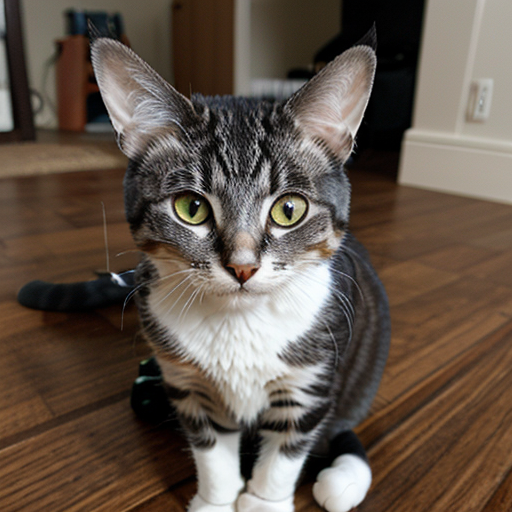

In [93]:
img=image.load_img('/content/dog_cat_dataset/train/cat/00000-4122619873.png')
img

In [81]:
result=cnn.predict(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


In [82]:
train_set1.class_indices
if result[0][0]==1:
  prediction='Dog'
else:
  prediction='Cat'

In [83]:
print(prediction)

Cat


In [84]:
#testing on dog image
test_img1=image.load_img('/content/dog_cat_dataset/test/dog/00510-3846168672.png',target_size=(64,64))
test_img1=image.img_to_array(test_img1)
test_img1=np.expand_dims(test_img1,axis=0)
result=cnn.predict(test_img1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


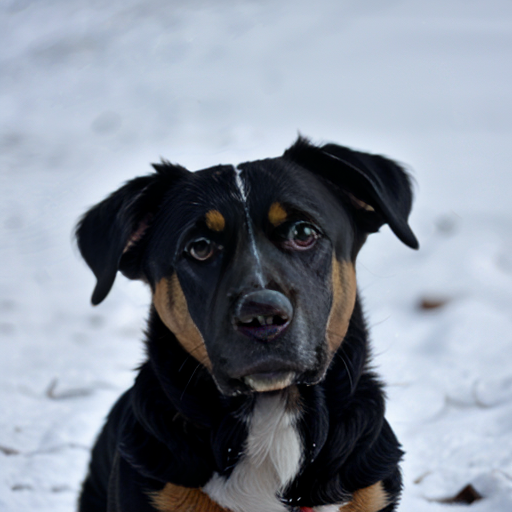

In [94]:
img=image.load_img('/content/dog_cat_dataset/test/dog/00510-3846168672.png')
img

In [85]:
train_set1.class_indices
if result[0][0]==1:
  prediction='Dog'
else:
  prediction='Cat'

In [86]:
print(prediction)

Dog
